# Блок 4 • Занятие 4 — Формула Байеса: обновление вероятностей + наивный скоринг (TODO)
**Дата:** 2026-03-02  
**Формат:** мини-теория → 10 кодовых ячеек → автопроверка (`assert`) → Run all  
**Цель занятия:** понять **формулу Байеса** и уметь применять её для простого “скоринга” (оценки вероятности) по данным.

---

## Мини-теория (термины, особенности, синтаксис)

### 1) Смысл формулы Байеса
Байес отвечает на вопрос:
> “Как изменить мою уверенность, если пришла новая информация?”

Если:
- A — гипотеза (например, “клиент купит”)
- B — наблюдение/признак (например, “кликнул”)

Тогда:
> **P(A|B) = P(B|A) · P(A) / P(B)**

### 2) Что означают части формулы
- **P(A)** — prior (априорная вероятность) — “до того, как мы увидели признак”
- **P(B|A)** — likelihood (правдоподобие) — “насколько признак B типичен, если A правда”
- **P(B)** — evidence (нормировка) — “насколько часто B встречается вообще”
- **P(A|B)** — posterior (апостериорная) — “после того, как увидели B”

### 3) Почему это полезно в дипломе
Байес — очень практичная штука для:
- простого риск-скоринга (вероятность события)
- фильтрации/детекторов (спам/не спам, покупка/не покупка)
- объяснимого ИИ (“почему вероятность изменилась?”)

### 4) Синтаксис Python, который используем
- функции `def ...`
- `dict` для хранения частот
- циклы `for`
- списковые выражения
- `matplotlib` для наглядности

---

## Задача урока (перенос в VS Code)
Перенесите в проект:
- `src/math_stats.py`: `bayes_posterior`, `prob_from_counts`
- `src/analytics.py`: `build_binary_counts`, `score_buy_probability`, `laplace_smooth_prob`


---
## Ячейка 1/10 — Данные: события (clicked, bought)

Оцениваем вероятность покупки по признаку `clicked`.


In [41]:
records = [
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 1, "bought": 0},
]
print("n =", len(records))


n = 24


---
## Ячейка 2/10 — Счётчики (частоты) для Байеса

Нужны `n`, `count_A`, `count_B`, `count_A_and_B`.
Где:
- A: bought=1
- B: clicked=1


In [42]:
def build_binary_counts(recs: list[dict], a_key: str, b_key: str) -> dict:
    # TODO: посчитайте n, count_A, count_B, count_A_and_B и верните словарь

    n = len(recs)
    count_A = 0
    count_B = 0
    count_A_and_B = 0

    for rec in recs:
      a = int(rec[a_key])
      b = int(rec[b_key])
      if a not in (0, 1) or b not in (0, 1):
        raise ValueError(f"Invalid value for {a_key}: {a}")
      if a == 1:
        count_A += 1
      if b == 1:
        count_B += 1
      if a == 1 and b == 1:
        count_A_and_B += 1
    return {"n": n, "count_A": count_A, "count_B": count_B, "count_A_and_B": count_A_and_B}

counts = build_binary_counts(records, "bought", "clicked")
counts

{'n': 24, 'count_A': 8, 'count_B': 15, 'count_A_and_B': 6}

---
## Ячейка 3/10 — P = count / n (функция prob_from_counts)

Безопасно считаем вероятность из частоты.


In [43]:
def prob_from_counts(count: int, n: int) -> float:
    # TODO: проверьте n>0, корректность count и верните count/n
    # raise NotImplementedError("TODO: implement prob_from_counts")

    if n <= 0:
        raise ValueError("prob_from_counts: n must be > 0")
    if count < 0 or count > n:
        raise ValueError("prob_from_counts: invalid count")
    return count / n

print("P(bought)  =", prob_from_counts(counts["count_A"], counts["n"]))
print("P(clicked) =", prob_from_counts(counts["count_B"], counts["n"]))


P(bought)  = 0.3333333333333333
P(clicked) = 0.625


---
## Ячейка 4/10 — Likelihood P(B|A) по данным

P(clicked | bought) = count(A∩B) / count(A)


In [44]:
def prob_conditional(count_A_and_B: int, count_A: int) -> float:
    # TODO: реализуйте безопасно и верните count_A_and_B/count_A
    # raise NotImplementedError("TODO: implement prob_conditional")

    if count_A <= 0:
        raise ValueError("prob_conditional: condition count must be > 0")
    if count_A_and_B < 0 or count_A_and_B > count_A:
        raise ValueError("prob_conditional: invalid intersection count")
    return count_A_and_B / count_A

p_B_given_A = prob_conditional(counts["count_A_and_B"], counts["count_A"])
print("P(clicked|bought) =", p_B_given_A)


P(clicked|bought) = 0.75


---
## Ячейка 5/10 — Формула Байеса (bayes_posterior)

P(bought|clicked) = P(clicked|bought)*P(bought)/P(clicked)


In [45]:
def bayes_posterior(prior: float, likelihood: float, evidence: float) -> float:
    # TODO: проверьте значения в [0,1], evidence>0, верните (likelihood*prior)/evidence

    for name, p in [("prior", prior), ("likelihood", likelihood), ("evidence", evidence)]:
        if p < 0 or p > 1:
            raise ValueError(f"bayes_posterior: {name} must be in [0,1]")
    if evidence == 0:
        raise ValueError("bayes_posterior: evidence must be > 0")
    return (likelihood * prior) / evidence

prior = prob_from_counts(counts["count_A"], counts["n"])
evidence = prob_from_counts(counts["count_B"], counts["n"])
likelihood = p_B_given_A

posterior = bayes_posterior(prior, likelihood, evidence)
print("P(bought|clicked) via Bayes =", posterior)

P(bought|clicked) via Bayes = 0.4


---
## Ячейка 6/10 — Проверка: прямой подсчёт vs Байес

Прямо из данных:
P(bought|clicked) = count(A∩B) / count(B)


In [46]:
# TODO: посчитайте direct и сравните с posterior
# raise NotImplementedError("TODO: implement comparison")

direct = counts["count_A_and_B"] / counts["count_B"]
print("direct =", direct)
print("bayes  =", posterior)
print("diff   =", abs(direct - posterior))


direct = 0.4
bayes  = 0.4
diff   = 0.0


---
## Ячейка 7/10 — Наивный скоринг: P(buy | clicked=value)

Если clicked=1 → используем P(buy|click=1)  
Если clicked=0 → используем P(buy|click=0)


In [47]:
def score_buy_probability(recs: list[dict], clicked_value: int) -> float:
    # TODO: отфильтруйте subset по clicked_value, посчитайте bought_count и верните bought_count/len(subset)
    # raise NotImplementedError("TODO: implement score_buy_probability")

    if clicked_value not in (0, 1):
        raise ValueError("clicked_value must be 0/1")
    subset = [r for r in recs if int(r["clicked"]) == clicked_value]
    if len(subset) == 0:
        raise ValueError("No records for clicked_value")
    bought_count = sum(1 for r in subset if int(r["bought"]) == 1)
    return bought_count / len(subset)

p_buy_click1 = score_buy_probability(records, 1)
p_buy_click0 = score_buy_probability(records, 0)

print("P(buy|click=1) =", p_buy_click1)
print("P(buy|click=0) =", p_buy_click0)


P(buy|click=1) = 0.4
P(buy|click=0) = 0.2222222222222222


---
## Ячейка 8/10 — График: prior vs posterior (matplotlib)

Показываем, как признак меняет вероятность.


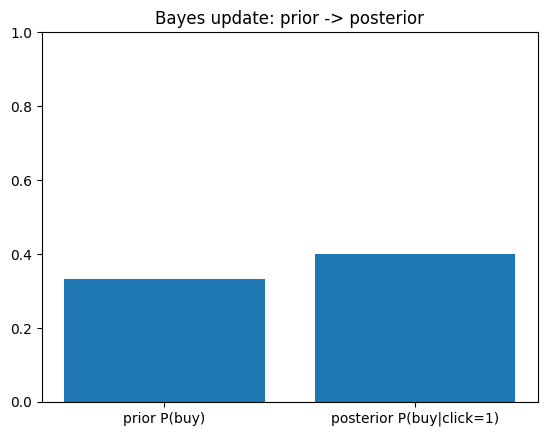

In [48]:
import matplotlib.pyplot as plt

# TODO: постройте bar chart для prior и posterior
# raise NotImplementedError("TODO: implement plot")
prior_buy = prob_from_counts(counts["count_A"], counts["n"])
posterior_buy_given_click1 = p_buy_click1

plt.bar(["prior P(buy)", "posterior P(buy|click=1)"], [prior_buy, posterior_buy_given_click1])
plt.ylim(0, 1)
plt.title("Bayes update: prior -> posterior")
plt.show()

---
## Ячейка 9/10 — Сглаживание Лапласа (Laplace smoothing)

Чтобы избежать нулевых вероятностей:
P = (successes + 1) / (trials + 2)


In [49]:
def laplace_smooth_prob(successes: int, trials: int) -> float:
    # TODO: проверьте корректность и верните (successes+1)/(trials+2)
    # raise NotImplementedError("TODO: implement laplace_smooth_prob")

    if trials < 0 or successes < 0 or successes > trials:
        raise ValueError("laplace_smooth_prob: invalid counts")
    return (successes + 1) / (trials + 2)

# TODO: посчитайте сглаженную вероятность для clicked=0
# raise NotImplementedError("TODO: compute smoothed probability")
subset0 = [r for r in records if int(r["clicked"]) == 0]
succ0 = sum(1 for r in subset0 if int(r["bought"]) == 1)
p_smooth0 = laplace_smooth_prob(succ0, len(subset0))

print("raw P(buy|click=0) =", p_buy_click0)
print("smooth P(buy|click=0) =", p_smooth0)


raw P(buy|click=0) = 0.2222222222222222
smooth P(buy|click=0) = 0.2727272727272727


---
## Ячейка 10/10 — Автопроверка (`assert`)

Run all → должны пройти все тесты.


In [50]:
# =========================
# BLOCK 04 — LESSON 04 TESTS (НЕ МЕНЯТЬ)
# =========================

def approx(a: float, b: float, eps: float = 1e-9) -> bool:
    return abs(a - b) <= eps

def run_all_tests():
    recs = [
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 1, "bought": 0},
    ]
    c = build_binary_counts(recs, "bought", "clicked")
    assert c == {"n": 24, "count_A": 8, "count_B": 15, "count_A_and_B": 6}

    prior = prob_from_counts(c["count_A"], c["n"])      # 8/24 = 1/3
    evidence = prob_from_counts(c["count_B"], c["n"])   # 15/24 = 5/8
    likelihood = prob_conditional(c["count_A_and_B"], c["count_A"])  # 6/8 = 3/4
    post = bayes_posterior(prior, likelihood, evidence) # (3/4 * 1/3) / (5/8) = 2/5

    assert approx(prior, 1/3)
    assert approx(evidence, 5/8)
    assert approx(likelihood, 3/4)
    assert approx(post, 2/5)

    direct = c["count_A_and_B"] / c["count_B"]
    assert approx(direct, post)

    p1 = score_buy_probability(recs, 1)  # 6/15 = 2/5
    p0 = score_buy_probability(recs, 0)  # 2/9
    assert approx(p1, 2/5)
    assert approx(p0, 2/9)

    assert approx(laplace_smooth_prob(0, 5), (0+1)/(5+2))
    assert laplace_smooth_prob(0, 5) > 0.0

    print("✅ BLOCK04 LESSON04: all tests passed")

run_all_tests()

✅ BLOCK04 LESSON04: all tests passed
